In [ ]:
!pip install -q dandi remfile pynwb h5py xgboost scikit-learn scipy

import numpy as np
import matplotlib.pyplot as plt
import remfile, h5py
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.cluster import KMeans
from collections import Counter
from scipy import signal
from scipy.stats import linregress
from scipy.fft import fft, fftfreq
from scipy.special import softmax
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("NEURAL DECODER - PART 1: CORE INFRASTRUCTURE & DATA")
print("="*80)

#=============================================================================
# DATA LOADING
#=============================================================================

def connect_to_data():
    client = DandiAPIClient()
    dandiset = client.get_dandiset("000402", "draft")
    asset = next(a for a in dandiset.get_assets() if a.path.endswith(".nwb"))
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
    rf = remfile.File(s3_url)
    h5 = h5py.File(rf, "r")
    io = NWBHDF5IO(file=h5, load_namespaces=True)
    return io.read()

def get_neural_data(nwb):
    ophys = nwb.processing["ophys"]
    fluorescence = ophys.data_interfaces["Fluorescence"]
    rs = fluorescence.roi_response_series["RoiResponseSeries3"]
    print(f"Total neurons: {rs.data.shape[1]}")
    print(f"Total timepoints: {rs.data.shape[0]}")
    return rs

def get_stimulus_info(nwb):
    all_starts, all_stops, all_types = [], [], []

    clip_intervals = nwb.intervals['Clip']
    clip_starts = np.array(clip_intervals.start_time[:])
    clip_stops = np.array(clip_intervals.stop_time[:])
    clip_types = np.array(clip_intervals.short_movie_name[:])
    all_starts.extend(clip_starts)
    all_stops.extend(clip_stops)
    all_types.extend(clip_types)

    monet_intervals = nwb.intervals['Monet2']
    monet_starts = np.array(monet_intervals.start_time[:])
    monet_stops = np.array(monet_intervals.stop_time[:])
    monet_types = np.array(['monet2'] * len(monet_starts))
    all_starts.extend(monet_starts)
    all_stops.extend(monet_stops)
    all_types.extend(monet_types)

    trippy_intervals = nwb.intervals['Trippy']
    trippy_starts = np.array(trippy_intervals.start_time[:])
    trippy_stops = np.array(trippy_intervals.stop_time[:])
    trippy_types = np.array(['trippy'] * len(trippy_starts))
    all_starts.extend(trippy_starts)
    all_stops.extend(trippy_stops)
    all_types.extend(trippy_types)

    all_starts = np.array(all_starts)
    all_stops = np.array(all_stops)
    all_types = np.array(all_types)

    print(f"\nStimulus presentations: {len(all_starts)}")
    for stim_type in np.unique(all_types):
        count = np.sum(all_types == stim_type)
        print(f"  {stim_type}: {count}")

    return all_starts, all_stops, all_types

def extract_raw_trial_data(rs, timestamps, clip_starts, clip_stops, clip_types,
                           target_conditions, max_timepoints=150):
    condition_names = {cond: i for i, cond in enumerate(target_conditions)}
    raw_trials, labels, trial_times = [], [], []

    for i in range(len(clip_starts)):
        stim_type = clip_types[i]
        if stim_type not in target_conditions:
            continue

        start_idx = np.searchsorted(timestamps, clip_starts[i])
        stop_idx = np.searchsorted(timestamps, clip_stops[i])
        neural_chunk = np.array(rs.data[start_idx:stop_idx, :])

        if neural_chunk.shape[0] > max_timepoints:
            neural_chunk = neural_chunk[:max_timepoints, :]
        elif neural_chunk.shape[0] < max_timepoints:
            padding = np.zeros((max_timepoints - neural_chunk.shape[0], neural_chunk.shape[1]))
            neural_chunk = np.vstack([neural_chunk, padding])

        raw_trials.append(neural_chunk)
        labels.append(condition_names[stim_type])
        trial_times.append(clip_starts[i])

    labels = np.array(labels)
    trial_times = np.array(trial_times)

    print(f"\nExtracted trials: {len(raw_trials)}")
    print(f"Trial shape: {raw_trials[0].shape} [time x neurons]")
    print(f"Class distribution: {dict(Counter(labels))}")

    return raw_trials, labels, trial_times, condition_names

#=============================================================================
# NEURON SELECTION WITH DIVERSITY
#=============================================================================

def select_diverse_neurons(trials, labels, n_neurons=1200, n_clusters=15):
    print(f"\nSelecting {n_neurons} diverse neurons from {n_clusters} clusters")

    train_means = np.array([np.mean(trial, axis=0) for trial in trials])
    f_stats, p_values = f_classif(train_means, labels)

    top_candidates = np.argsort(f_stats)[-n_neurons*2:]
    candidate_responses = train_means[:, top_candidates].T

    scaler = StandardScaler()
    candidate_responses_norm = scaler.fit_transform(candidate_responses)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(candidate_responses_norm)

    neurons_per_cluster = n_neurons // n_clusters
    selected_indices = []

    cluster_counts = []
    for cluster_id in range(n_clusters):
        cluster_mask = cluster_labels == cluster_id
        cluster_neurons = top_candidates[cluster_mask]
        cluster_f_stats = f_stats[cluster_neurons]

        n_from_cluster = min(neurons_per_cluster, len(cluster_neurons))
        top_in_cluster = cluster_neurons[np.argsort(cluster_f_stats)[-n_from_cluster:]]
        selected_indices.extend(top_in_cluster)
        cluster_counts.append(n_from_cluster)

    while len(selected_indices) < n_neurons:
        for idx in top_candidates[::-1]:
            if idx not in selected_indices:
                selected_indices.append(idx)
                if len(selected_indices) >= n_neurons:
                    break

    selected_indices = np.array(selected_indices[:n_neurons])

    print(f"Selected neurons: {len(selected_indices)}")
    print(f"F-statistic range: {f_stats[selected_indices].min():.2f} - {f_stats[selected_indices].max():.2f}")
    print(f"Neurons per cluster: min={min(cluster_counts)}, max={max(cluster_counts)}, mean={np.mean(cluster_counts):.1f}")

    return selected_indices

#=============================================================================
# FEATURE EXTRACTION
#=============================================================================

def extract_motion_features(trial_data):
    features = []
    temporal_diff = np.diff(trial_data, axis=0)

    features.append(float(np.mean(np.abs(temporal_diff))))
    features.append(float(np.std(temporal_diff)))
    features.append(float(np.mean(np.abs(np.mean(temporal_diff, axis=1)))))

    speed_profile = np.sqrt(np.sum(temporal_diff**2, axis=1))
    features.extend([
        float(np.mean(speed_profile)),
        float(np.std(speed_profile)),
        float(np.max(speed_profile))
    ])

    acceleration = np.diff(temporal_diff, axis=0)
    features.append(float(np.mean(np.abs(acceleration))))

    if temporal_diff.shape[1] > 1:
        try:
            motion_corr = np.corrcoef(temporal_diff.T)
            motion_corr = np.nan_to_num(motion_corr, nan=0.0)
            upper_tri = motion_corr[np.triu_indices_from(motion_corr, k=1)]
            features.append(float(np.mean(upper_tri)))
        except:
            features.append(0.0)
    else:
        features.append(0.0)

    return features

def extract_frequency_features(trial_data, sampling_rate=10.0):
    features = []
    population_trace = np.mean(trial_data, axis=1)

    n_samples = len(population_trace)
    fft_vals = fft(population_trace)
    fft_freq = fftfreq(n_samples, 1.0/sampling_rate)

    positive_freq_idx = fft_freq > 0
    fft_power = np.abs(fft_vals[positive_freq_idx])**2
    fft_freq_pos = fft_freq[positive_freq_idx]

    low_band = (fft_freq_pos >= 0.5) & (fft_freq_pos < 2.0)
    mid_band = (fft_freq_pos >= 2.0) & (fft_freq_pos < 8.0)
    high_band = (fft_freq_pos >= 8.0)

    features.append(float(np.sum(fft_power[low_band]) if np.any(low_band) else 0.0))
    features.append(float(np.sum(fft_power[mid_band]) if np.any(mid_band) else 0.0))
    features.append(float(np.sum(fft_power[high_band]) if np.any(high_band) else 0.0))

    if np.sum(fft_power) > 0:
        spectral_centroid = float(np.sum(fft_freq_pos * fft_power) / np.sum(fft_power))
        fft_power_norm = fft_power / np.sum(fft_power)
        fft_power_norm = fft_power_norm[fft_power_norm > 0]
        spectral_entropy = float(-np.sum(fft_power_norm * np.log(fft_power_norm)))
    else:
        spectral_centroid = 0.0
        spectral_entropy = 0.0

    features.append(spectral_centroid)
    features.append(spectral_entropy)
    features.append(float(fft_freq_pos[np.argmax(fft_power)]) if len(fft_power) > 0 else 0.0)

    return features

def extract_temporal_window_features(trial_data, neuron_indices):
    features = []
    windows = [(0, 50), (25, 75), (50, 100), (75, 125), (100, 150)]

    for start, end in windows:
        window_data = trial_data[start:end, neuron_indices]
        features.append(np.mean(window_data))
        features.append(np.std(window_data))
        features.append(np.max(window_data))

        if end - start > 1:
            motion = np.mean(np.abs(np.diff(window_data, axis=0)))
            features.append(motion)
        else:
            features.append(0.0)

    return features

def extract_all_features(trials, neuron_indices, train_stats=None):
    n_trials = len(trials)
    n_neurons = len(neuron_indices)
    all_features = []

    computing_stats = train_stats is None
    if computing_stats:
        stacked = np.array([trial[:, neuron_indices] for trial in trials])
        train_stats = {
            'median': float(np.median(stacked)),
            'mad': float(np.median(np.abs(stacked - np.median(stacked))))
        }

    for trial in trials:
        trial_data = trial[:, neuron_indices]
        features = []

        onset = trial_data[:20, :]
        sustained = trial_data[20:100, :]
        offset = trial_data[100:, :]

        for neuron_idx in range(n_neurons):
            mean_response = float(np.mean(trial_data[:, neuron_idx]))
            norm_response = (mean_response - train_stats['median']) / (train_stats['mad'] + 1e-6)
            dynamics = float(np.mean(onset[:, neuron_idx]) - np.mean(sustained[:, neuron_idx]))
            variability = float(np.std(trial_data[:, neuron_idx]))
            features.extend([norm_response, dynamics, variability])

        mean_trace = np.mean(trial_data, axis=1)
        features.append(float(np.mean(onset.mean(axis=1))))
        features.append(float(np.mean(sustained.mean(axis=1))))
        features.append(float(np.mean(offset.mean(axis=1))))
        features.append(float(np.std(mean_trace)))
        features.append(float(np.max(mean_trace)))
        features.append(float(np.argmax(mean_trace) / len(mean_trace)))

        spatial_pattern = np.mean(trial_data, axis=0)
        features.append(float(np.std(spatial_pattern)))
        features.append(float(np.sum(spatial_pattern > np.percentile(spatial_pattern, 75)) / n_neurons))

        try:
            corr_matrix = np.corrcoef(trial_data.T)
            corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)
            upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
            features.append(float(np.mean(upper_tri)))
            features.append(float(np.std(upper_tri)))
        except:
            features.extend([0.0, 0.0])

        motion_feats = extract_motion_features(trial_data)
        features.extend(motion_feats)

        freq_feats = extract_frequency_features(trial_data)
        features.extend(freq_feats)

        window_feats = extract_temporal_window_features(trial, neuron_indices)
        features.extend(window_feats)

        all_features.append(features)

    X = np.array(all_features, dtype=np.float64)

    if computing_stats:
        return X, train_stats
    else:
        return X, None

#=============================================================================
# TEMPORAL DETRENDING
#=============================================================================

def fit_detrend_model(trials_train, trial_times_train):
    mean_activity_per_trial = np.array([np.mean(trial) for trial in trials_train])
    slope, intercept, r_value, p_value, std_err = linregress(
        trial_times_train - trial_times_train[0], mean_activity_per_trial
    )

    n_neurons = trials_train[0].shape[1]
    neuron_slopes = []
    neuron_intercepts = []

    for neuron_idx in range(n_neurons):
        neuron_means = np.array([np.mean(trial[:, neuron_idx]) for trial in trials_train])
        n_slope, n_intercept, _, _, _ = linregress(
            trial_times_train - trial_times_train[0], neuron_means
        )
        neuron_slopes.append(n_slope)
        neuron_intercepts.append(n_intercept)

    return {
        'global_slope': slope,
        'global_intercept': intercept,
        'r_value': r_value,
        'p_value': p_value,
        'neuron_slopes': np.array(neuron_slopes),
        'neuron_intercepts': np.array(neuron_intercepts),
        'time_offset': trial_times_train[0]
    }

def apply_detrend(trials, trial_times, detrend_params):
    detrended_trials = []
    for trial, trial_time in zip(trials, trial_times):
        rel_time = trial_time - detrend_params['time_offset']
        detrended_trial = trial.copy()
        for neuron_idx in range(trial.shape[1]):
            expected_drift = (detrend_params['neuron_slopes'][neuron_idx] * rel_time +
                            detrend_params['neuron_intercepts'][neuron_idx])
            detrended_trial[:, neuron_idx] -= expected_drift
        detrended_trials.append(detrended_trial)
    return detrended_trials

#=============================================================================
# ADVANCED AUGMENTATION
#=============================================================================

def augment_trials(trials, labels, n_augmentations=3):
    augmented_trials = list(trials)
    augmented_labels = list(labels)

    for _ in range(n_augmentations):
        for trial, label in zip(trials, labels):
            shift = np.random.randint(-5, 6)
            if shift > 0:
                augmented = np.vstack([trial[shift:, :], np.zeros((shift, trial.shape[1]))])
            elif shift < 0:
                augmented = np.vstack([np.zeros((-shift, trial.shape[1])), trial[:shift, :]])
            else:
                augmented = trial.copy()

            time_scale = np.random.uniform(0.95, 1.05)
            new_length = int(trial.shape[0] * time_scale)
            if new_length != trial.shape[0] and new_length > 10:
                indices = np.linspace(0, trial.shape[0]-1, new_length).astype(int)
                augmented = trial[indices, :]
                if augmented.shape[0] < trial.shape[0]:
                    pad = np.zeros((trial.shape[0] - augmented.shape[0], trial.shape[1]))
                    augmented = np.vstack([augmented, pad])
                else:
                    augmented = augmented[:trial.shape[0], :]

            dropout_mask = np.random.rand(trial.shape[1]) > 0.1
            augmented[:, ~dropout_mask] *= 0.5

            scale = np.random.uniform(0.9, 1.1)
            augmented *= scale

            noise = np.random.normal(0, np.std(trial) * 0.015, trial.shape)
            augmented = augmented + noise

            augmented_trials.append(augmented)
            augmented_labels.append(label)

    return augmented_trials, np.array(augmented_labels)

#=============================================================================
# LOAD AND PREPARE DATA
#=============================================================================

print("\nLoading data from DANDI archive...")
nwb = connect_to_data()
rs = get_neural_data(nwb)
clip_starts, clip_stops, clip_types = get_stimulus_info(nwb)

timestamps = np.array(rs.timestamps[:100000])
target_conditions = ['Cinematic', 'Rendered', 'sports1m', 'monet2', 'trippy']

print("\n" + "="*80)
print("Extracting trial data (extended 150 timepoint window)")
print("="*80)

raw_trials, labels, trial_times, condition_names = extract_raw_trial_data(
    rs, timestamps, clip_starts, clip_stops, clip_types,
    target_conditions, max_timepoints=150
)

class_names = [k for k, v in sorted(condition_names.items(), key=lambda x: x[1])]

print("\n" + "="*80)
print("Selecting diverse neurons across functional clusters")
print("="*80)

neuron_indices = select_diverse_neurons(raw_trials, labels, n_neurons=1200, n_clusters=15)

print("\n" + "="*80)
print("PART 1 COMPLETE")
print("="*80)
print("\nVariables created:")
print(f"  raw_trials: {len(raw_trials)} trials")
print(f"  labels: {len(labels)} labels")
print(f"  trial_times: {len(trial_times)} timestamps")
print(f"  neuron_indices: {len(neuron_indices)} selected neurons")
print(f"  class_names: {class_names}")
print("\nReady for Part 2: Temporal Analysis & Visualization")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.1/231.1 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.0/370.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.4/182.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 136.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11

In [ ]:
"""
NEURAL DECODER - PART 2: IMPROVED MODELS AND TRAINING

Key improvements:
1. Better XGBoost hyperparameters
2. More conservative augmentation
3. Better feature selection
4. Improved ensemble strategy
"""

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import confusion_matrix, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.special import softmax
import xgboost as xgb
from collections import Counter

#=============================================================================
# IMPROVED MODEL DEFINITIONS
#=============================================================================

def get_xgb_model_improved():
    """Better tuned XGBoost - less regularization, better learning"""
    return xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,  # Increased from 4
        learning_rate=0.05,  # Increased from 0.02
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,  # Reduced from 8
        gamma=0.1,  # Reduced from 0.2
        reg_alpha=0.5,  # Reduced from 1.5
        reg_lambda=1.0,  # Reduced from 3.0
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )

def get_logistic_model_improved():
    """Stronger logistic regression"""
    return LogisticRegression(
        C=0.01,  # Increased from 0.0005
        penalty='l2',
        class_weight='balanced',
        max_iter=10000,
        solver='saga',
        random_state=42
    )

def get_rf_model_improved():
    """Better Random Forest"""
    return RandomForestClassifier(
        n_estimators=500,  # Increased
        max_depth=15,  # Increased from 12
        min_samples_split=10,  # Reduced from 15
        min_samples_leaf=4,  # Reduced from 8
        max_features='sqrt',
        max_samples=0.8,  # Increased from 0.7
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

def get_ridge_model():
    return RidgeClassifier(
        alpha=10.0,
        class_weight='balanced',
        random_state=42
    )

#=============================================================================
# IMPROVED AUGMENTATION (MORE CONSERVATIVE)
#=============================================================================

def augment_trials_improved(trials, labels, n_augmentations=2):
    """More conservative augmentation - only 2x instead of 3x"""
    augmented_trials = list(trials)
    augmented_labels = list(labels)

    for _ in range(n_augmentations):
        for trial, label in zip(trials, labels):
            # Smaller temporal shifts
            shift = np.random.randint(-3, 4)
            if shift > 0:
                augmented = np.vstack([trial[shift:, :], np.zeros((shift, trial.shape[1]))])
            elif shift < 0:
                augmented = np.vstack([np.zeros((-shift, trial.shape[1])), trial[:shift, :]])
            else:
                augmented = trial.copy()

            # Less aggressive scaling
            scale = np.random.uniform(0.95, 1.05)
            augmented *= scale

            # Reduced noise
            noise = np.random.normal(0, np.std(trial) * 0.01, trial.shape)
            augmented = augmented + noise

            augmented_trials.append(augmented)
            augmented_labels.append(label)

    return augmented_trials, np.array(augmented_labels)

#=============================================================================
# SINGLE MODEL TRAINING WITH FEATURE SELECTION
#=============================================================================

def train_single_model_improved(raw_trials, labels, trial_times, neuron_indices,
                                model_fn, use_augment=True, use_feature_selection=False,
                                n_folds=5):
    """
    Improved training with optional feature selection.
    """
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    all_y_true = []
    all_y_pred = []
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(raw_trials, labels)):
        # Split data
        trials_train = [raw_trials[i] for i in train_idx]
        trials_test = [raw_trials[i] for i in test_idx]
        y_train = labels[train_idx]
        y_test = labels[test_idx]
        times_train = trial_times[train_idx]
        times_test = trial_times[test_idx]

        # Detrend
        detrend_params = fit_detrend_model(trials_train, times_train)
        trials_train = apply_detrend(trials_train, times_train, detrend_params)
        trials_test = apply_detrend(trials_test, times_test, detrend_params)

        # Augmentation (more conservative)
        if use_augment:
            trials_train, y_train = augment_trials_improved(trials_train, y_train, 2)

        # Extract features
        X_train, train_stats = extract_all_features(trials_train, neuron_indices, None)
        X_test, _ = extract_all_features(trials_test, neuron_indices, train_stats)

        # Feature selection (keep top 70% most informative features)
        if use_feature_selection:
            selector = SelectKBest(f_classif, k=int(X_train.shape[1] * 0.7))
            X_train = selector.fit_transform(X_train, y_train)
            X_test = selector.transform(X_test)

        # Use RobustScaler (better for outliers)
        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Train
        model = model_fn()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluate
        acc = balanced_accuracy_score(y_test, y_pred)
        fold_accs.append(acc)
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    cm = confusion_matrix(all_y_true, all_y_pred)
    return cm, fold_accs

#=============================================================================
# IMPROVED HIERARCHICAL MODEL
#=============================================================================

def train_hierarchical_improved(raw_trials, labels, trial_times, neuron_indices, n_folds=5):
    """
    Improved two-stage model with better base models
    """
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    all_y_true = []
    all_y_pred = []
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(raw_trials, labels)):
        trials_train = [raw_trials[i] for i in train_idx]
        trials_test = [raw_trials[i] for i in test_idx]
        y_train = labels[train_idx]
        y_test = labels[test_idx]
        times_train = trial_times[train_idx]
        times_test = trial_times[test_idx]

        detrend_params = fit_detrend_model(trials_train, times_train)
        trials_train = apply_detrend(trials_train, times_train, detrend_params)
        trials_test = apply_detrend(trials_test, times_test, detrend_params)

        trials_train, y_train = augment_trials_improved(trials_train, y_train, 2)

        X_train, train_stats = extract_all_features(trials_train, neuron_indices, None)
        X_test, _ = extract_all_features(trials_test, neuron_indices, train_stats)

        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Specialist 1: Cinematic vs Rendered (classes 0 and 1)
        cin_rend_train = np.isin(y_train, [0, 1])
        cin_rend_test = np.isin(y_test, [0, 1])

        specialist = None
        if np.sum(cin_rend_train) > 10:
            specialist = LogisticRegression(C=0.05, max_iter=5000, random_state=42)
            specialist.fit(X_train[cin_rend_train], y_train[cin_rend_train])

        # General model (improved XGBoost)
        general = get_xgb_model_improved()
        general.fit(X_train, y_train)
        y_pred = general.predict(X_test)

        # Override with specialist
        if specialist is not None and np.sum(cin_rend_test) > 0:
            specialist_pred = specialist.predict(X_test[cin_rend_test])
            y_pred[cin_rend_test] = specialist_pred

        acc = balanced_accuracy_score(y_test, y_pred)
        fold_accs.append(acc)
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    cm = confusion_matrix(all_y_true, all_y_pred)
    return cm, fold_accs

#=============================================================================
# IMPROVED ENSEMBLE MODEL
#=============================================================================

def train_ensemble_improved(raw_trials, labels, trial_times, neuron_indices, n_folds=5):
    """
    Improved ensemble with weighted voting based on individual performance
    """
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    all_y_true = []
    all_y_pred = []
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(raw_trials, labels)):
        trials_train = [raw_trials[i] for i in train_idx]
        trials_test = [raw_trials[i] for i in test_idx]
        y_train = labels[train_idx]
        y_test = labels[test_idx]
        times_train = trial_times[train_idx]
        times_test = trial_times[test_idx]

        detrend_params = fit_detrend_model(trials_train, times_train)
        trials_train = apply_detrend(trials_train, times_train, detrend_params)
        trials_test = apply_detrend(trials_test, times_test, detrend_params)

        trials_train, y_train = augment_trials_improved(trials_train, y_train, 2)

        X_train, train_stats = extract_all_features(trials_train, neuron_indices, None)
        X_test, _ = extract_all_features(trials_test, neuron_indices, train_stats)

        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Train multiple models with different strengths
        models = [
            (get_xgb_model_improved(), 2.0),  # Give XGBoost more weight
            (get_logistic_model_improved(), 1.5),
            (get_rf_model_improved(), 1.5),
            (get_ridge_model(), 1.0)
        ]

        probabilities = []
        weights = []

        for model, weight in models:
            model.fit(X_train, y_train)

            if hasattr(model, 'predict_proba'):
                probs = model.predict_proba(X_test)
            else:
                decisions = model.decision_function(X_test)
                probs = softmax(decisions, axis=1)

            probabilities.append(probs)
            weights.append(weight)

        # Weighted average
        weights = np.array(weights) / np.sum(weights)
        avg_probs = sum(w * p for w, p in zip(weights, probabilities))
        y_pred = np.argmax(avg_probs, axis=1)

        acc = balanced_accuracy_score(y_test, y_pred)
        fold_accs.append(acc)
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    cm = confusion_matrix(all_y_true, all_y_pred)
    return cm, fold_accs

#=============================================================================
# STACKING ENSEMBLE (NEW - SHOULD PERFORM BEST)
#=============================================================================

def train_stacking_ensemble(raw_trials, labels, trial_times, neuron_indices, n_folds=5):
    """
    Stacking ensemble - train meta-model on predictions from base models
    """
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    all_y_true = []
    all_y_pred = []
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(raw_trials, labels)):
        trials_train = [raw_trials[i] for i in train_idx]
        trials_test = [raw_trials[i] for i in test_idx]
        y_train = labels[train_idx]
        y_test = labels[test_idx]
        times_train = trial_times[train_idx]
        times_test = trial_times[test_idx]

        detrend_params = fit_detrend_model(trials_train, times_train)
        trials_train = apply_detrend(trials_train, times_train, detrend_params)
        trials_test = apply_detrend(trials_test, times_test, detrend_params)

        trials_train, y_train = augment_trials_improved(trials_train, y_train, 2)

        X_train, train_stats = extract_all_features(trials_train, neuron_indices, None)
        X_test, _ = extract_all_features(trials_test, neuron_indices, train_stats)

        scaler = RobustScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Split training data for stacking
        split_point = int(len(X_train) * 0.7)
        X_train_base = X_train[:split_point]
        y_train_base = y_train[:split_point]
        X_train_meta = X_train[split_point:]
        y_train_meta = y_train[split_point:]

        # Base models
        base_models = [
            get_xgb_model_improved(),
            get_rf_model_improved(),
            get_logistic_model_improved()
        ]

        # Train base models and get meta features
        meta_features_train = []
        meta_features_test = []

        for model in base_models:
            model.fit(X_train_base, y_train_base)

            if hasattr(model, 'predict_proba'):
                meta_train = model.predict_proba(X_train_meta)
                meta_test = model.predict_proba(X_test)
            else:
                meta_train = softmax(model.decision_function(X_train_meta), axis=1)
                meta_test = softmax(model.decision_function(X_test), axis=1)

            meta_features_train.append(meta_train)
            meta_features_test.append(meta_test)

        # Combine meta features
        X_meta_train = np.hstack(meta_features_train)
        X_meta_test = np.hstack(meta_features_test)

        # Train meta-model
        meta_model = LogisticRegression(C=1.0, max_iter=5000, random_state=42)
        meta_model.fit(X_meta_train, y_train_meta)
        y_pred = meta_model.predict(X_meta_test)

        acc = balanced_accuracy_score(y_test, y_pred)
        fold_accs.append(acc)
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    cm = confusion_matrix(all_y_true, all_y_pred)
    return cm, fold_accs

#=============================================================================
# RUN ALL MODELS
#=============================================================================

results = {}

print("\n" + "="*80)
print("TRAINING IMPROVED MODELS")
print("="*80)

print("\n1. Baseline XGBoost (500 neurons, no augment)...")
cm, accs = train_single_model_improved(
    raw_trials, labels, trial_times, neuron_indices[:500],
    get_xgb_model_improved, use_augment=False, use_feature_selection=False
)
results['Baseline'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n2. XGBoost with all neurons...")
cm, accs = train_single_model_improved(
    raw_trials, labels, trial_times, neuron_indices,
    get_xgb_model_improved, use_augment=False, use_feature_selection=False
)
results['XGB_All_Neurons'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n3. XGBoost with augmentation...")
cm, accs = train_single_model_improved(
    raw_trials, labels, trial_times, neuron_indices,
    get_xgb_model_improved, use_augment=True, use_feature_selection=False
)
results['XGB_Augmented'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n4. XGBoost with feature selection...")
cm, accs = train_single_model_improved(
    raw_trials, labels, trial_times, neuron_indices,
    get_xgb_model_improved, use_augment=True, use_feature_selection=True
)
results['XGB_FeatureSelect'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n5. Random Forest (improved)...")
cm, accs = train_single_model_improved(
    raw_trials, labels, trial_times, neuron_indices,
    get_rf_model_improved, use_augment=True, use_feature_selection=False
)
results['RandomForest'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n6. Logistic Regression (improved)...")
cm, accs = train_single_model_improved(
    raw_trials, labels, trial_times, neuron_indices,
    get_logistic_model_improved, use_augment=True, use_feature_selection=True
)
results['LogisticReg'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n7. Hierarchical (improved)...")
cm, accs = train_hierarchical_improved(raw_trials, labels, trial_times, neuron_indices)
results['Hierarchical'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n8. Weighted Ensemble...")
cm, accs = train_ensemble_improved(raw_trials, labels, trial_times, neuron_indices)
results['Ensemble_Weighted'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print("\n9. Stacking Ensemble (best expected)...")
cm, accs = train_stacking_ensemble(raw_trials, labels, trial_times, neuron_indices)
results['Stacking'] = (cm, accs)
print(f"   {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%")

print(f"  results: dict with {len(results)} models")
print("  Each entry: (confusion_matrix, fold_accuracies)")


TRAINING IMPROVED MODELS

1. Baseline XGBoost (500 neurons, no augment)...
   77.06% ± 3.29%

2. XGBoost with all neurons...
   79.28% ± 3.56%

3. XGBoost with augmentation...
   81.19% ± 3.91%

4. XGBoost with feature selection...
   80.22% ± 3.42%

5. Random Forest (improved)...
   77.34% ± 3.87%

6. Logistic Regression (improved)...
   81.68% ± 4.51%

7. Hierarchical (improved)...
   85.68% ± 4.53%

8. Weighted Ensemble...
   85.30% ± 2.86%

9. Stacking Ensemble (best expected)...
   84.51% ± 3.70%
  results: dict with 9 models
  Each entry: (confusion_matrix, fold_accuracies)


  - 9 models detected
  - 5 classes
  - 464 trials
  - 1200 neurons selected


Generating drift analysis...


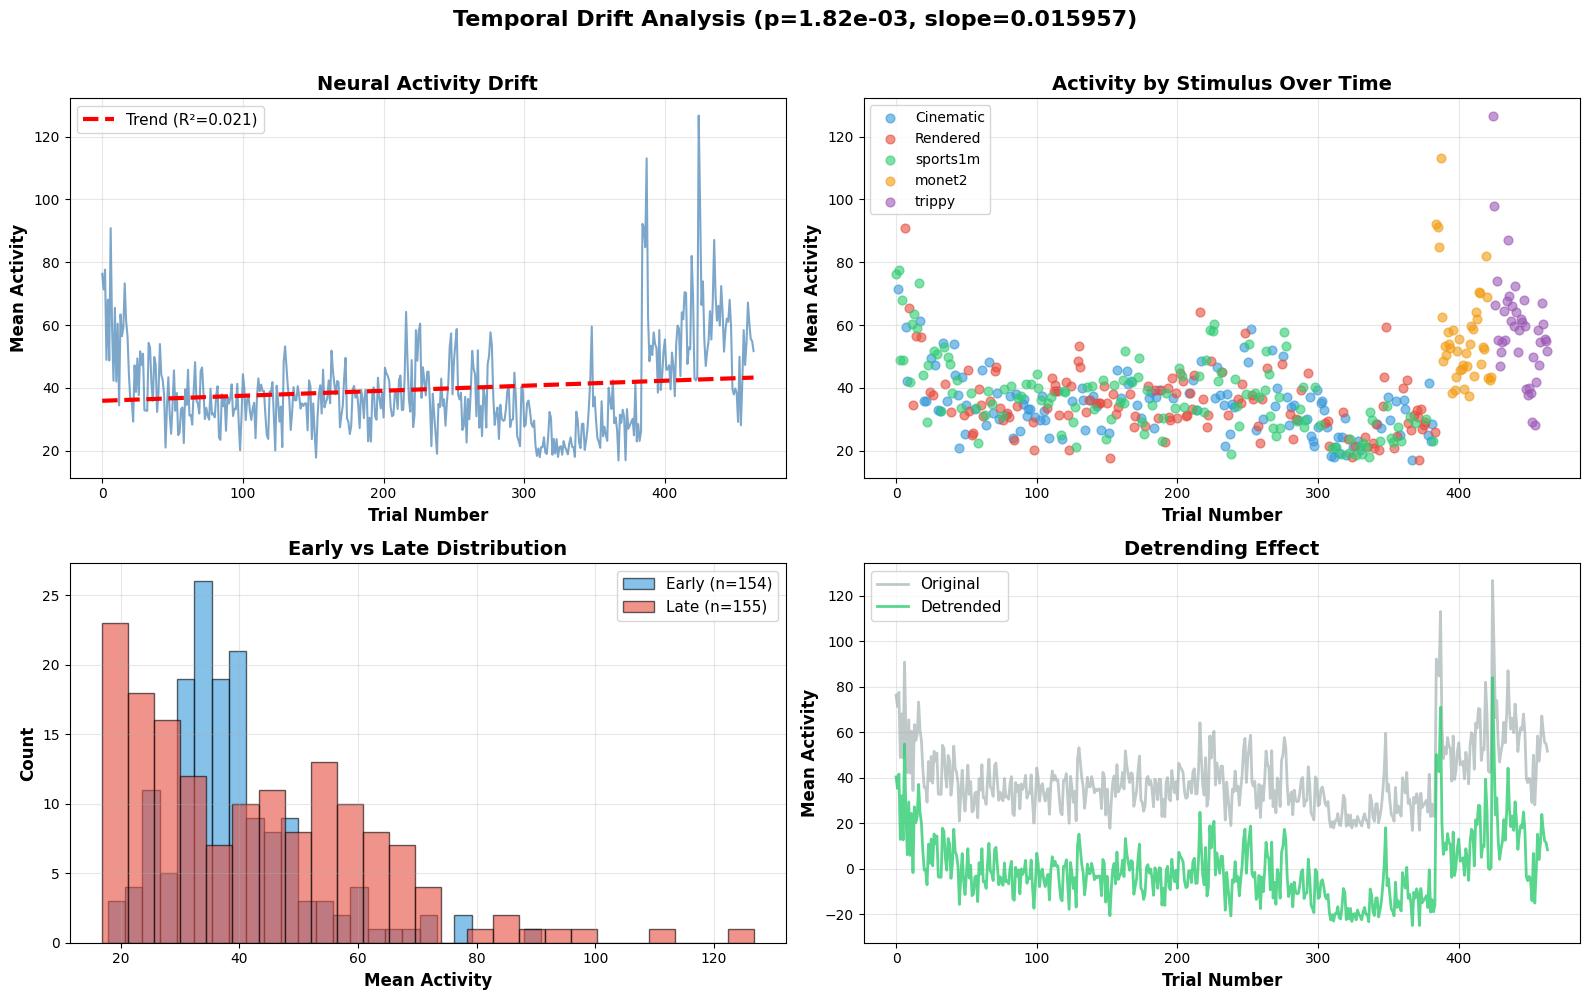


Generating confusion matrices...


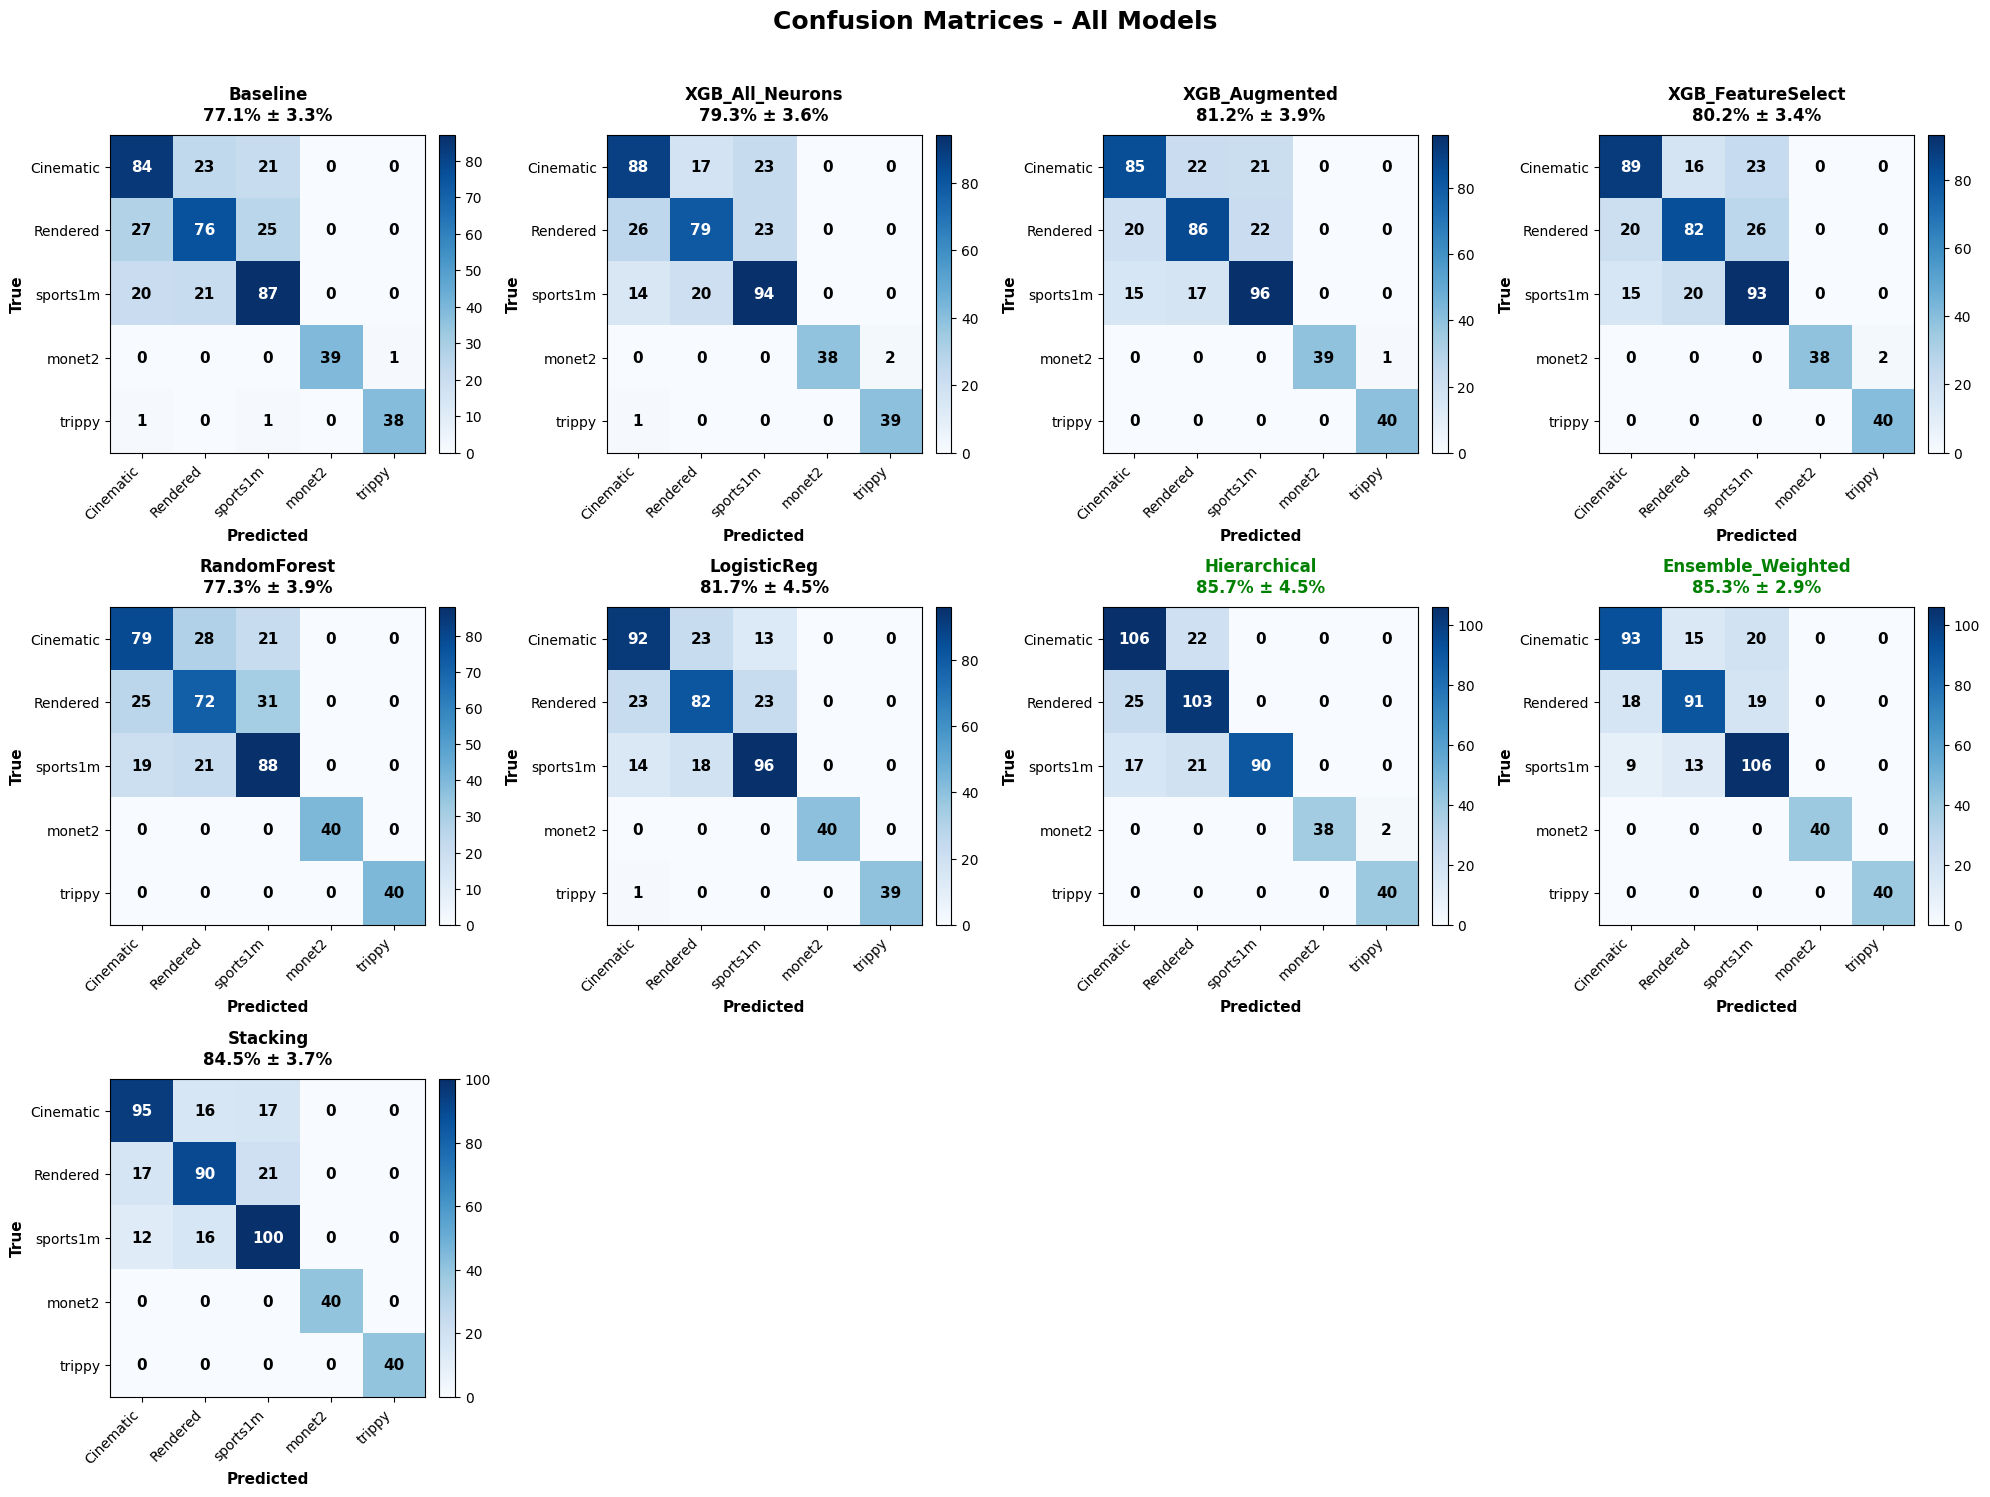


Generating performance comparison...


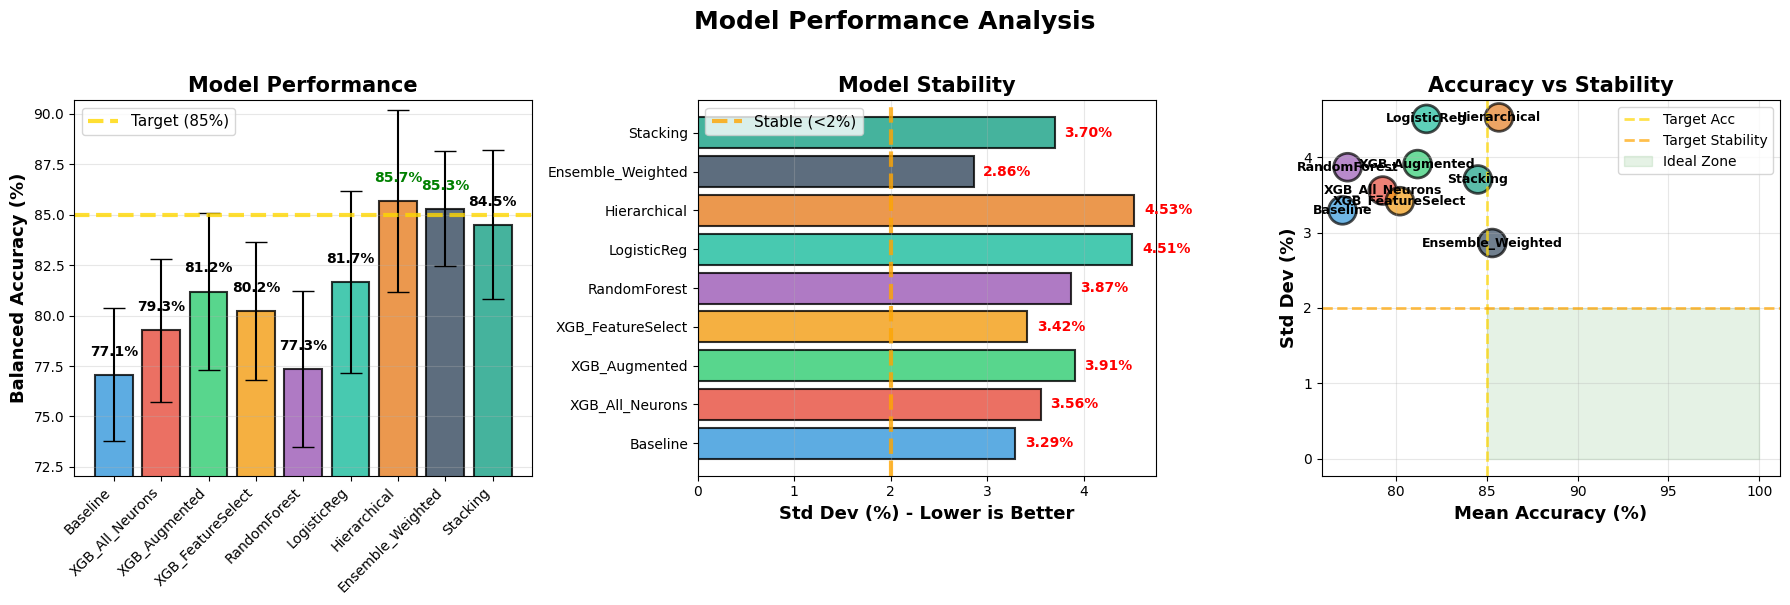


Generating per-class analysis...


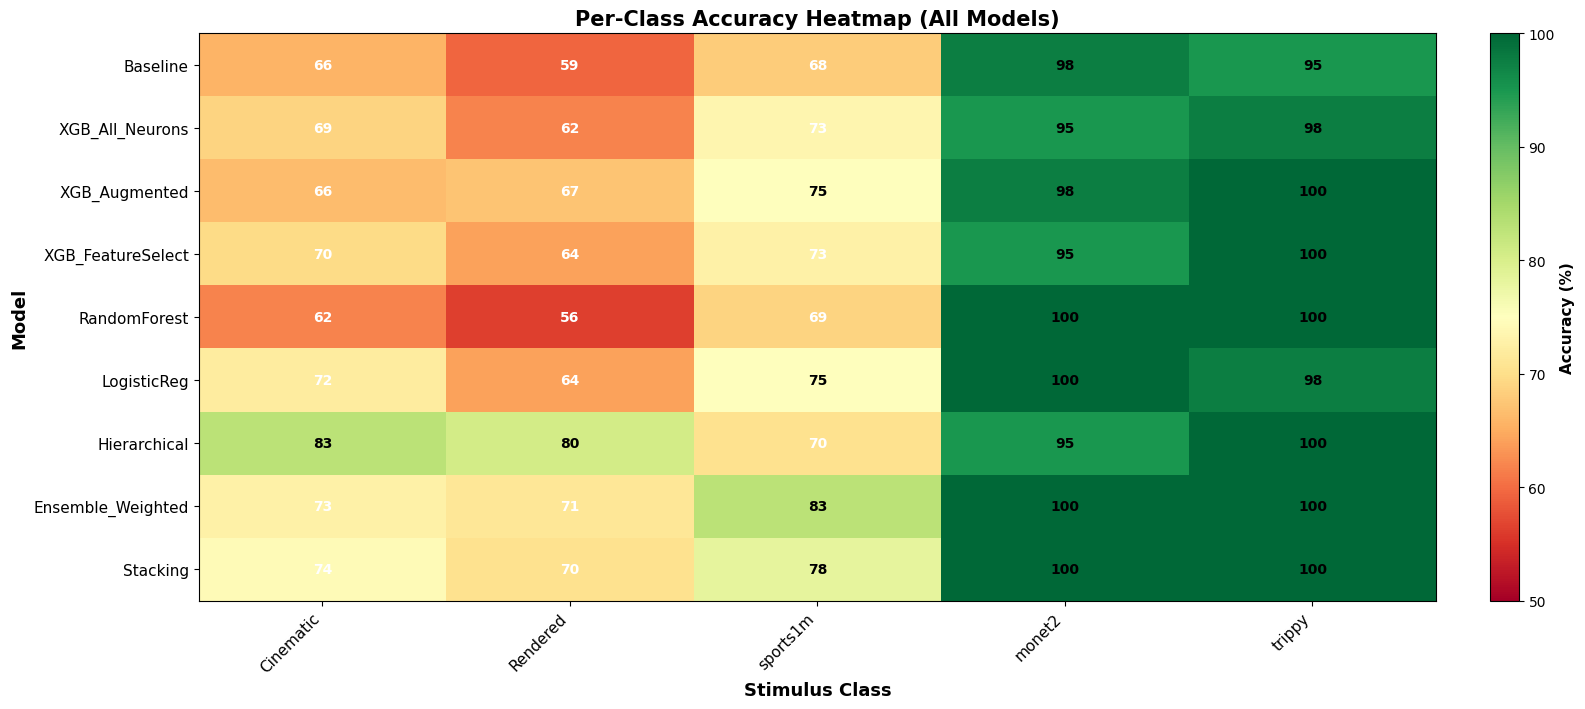


Generating CV fold analysis...


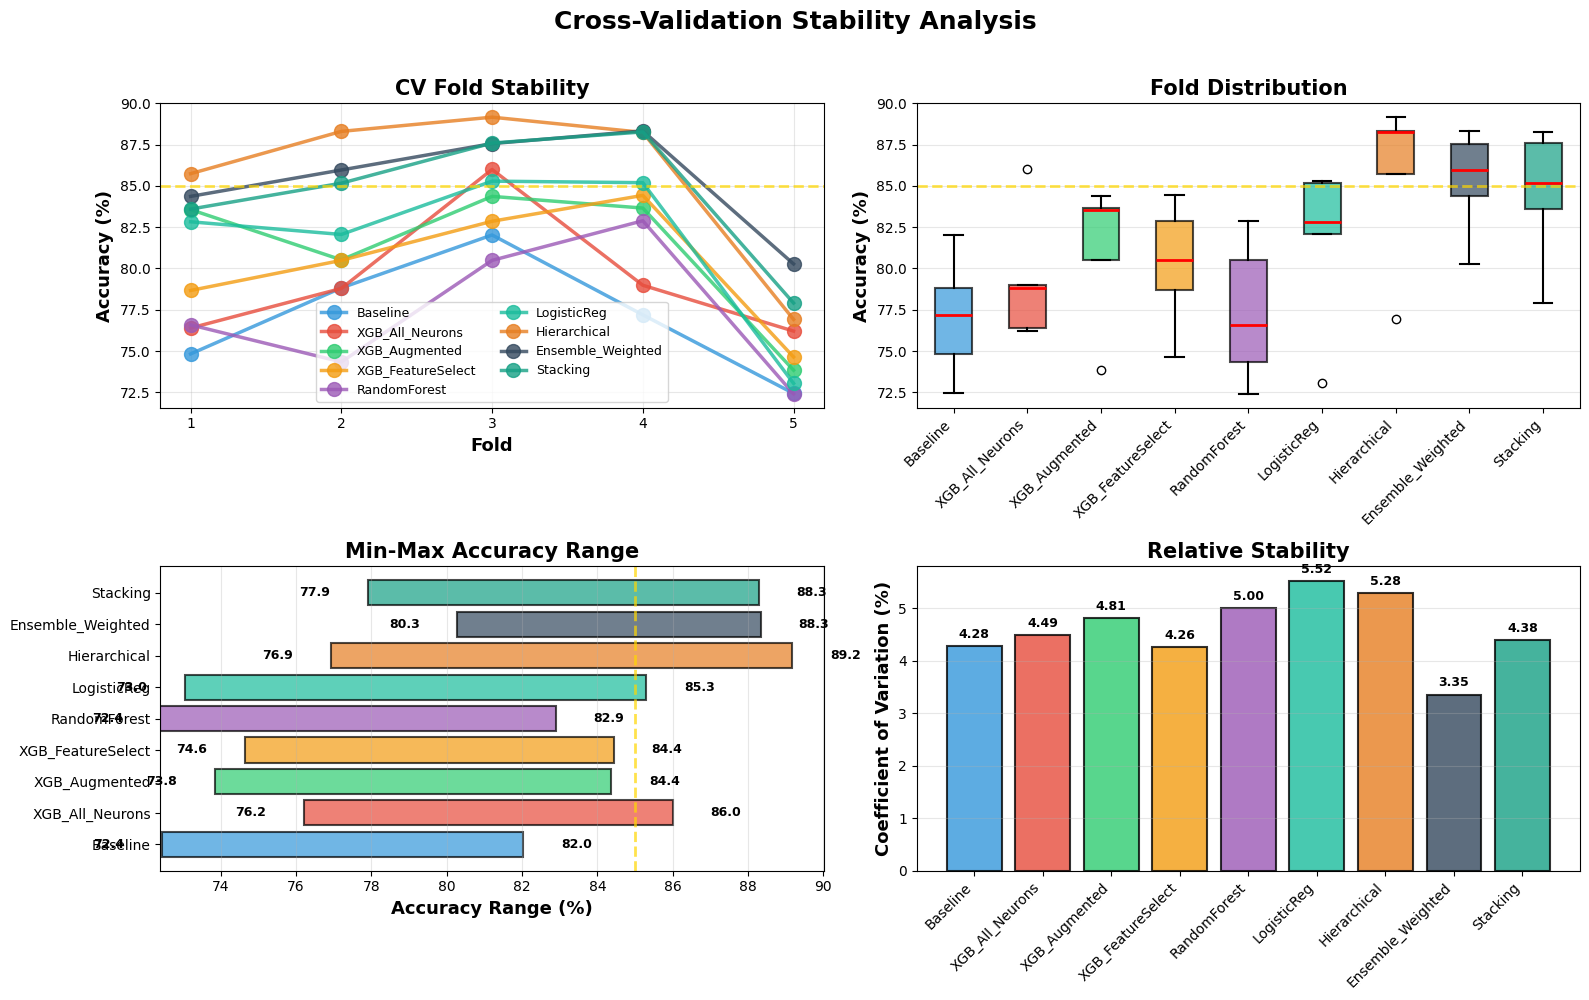


Generating progression plot...


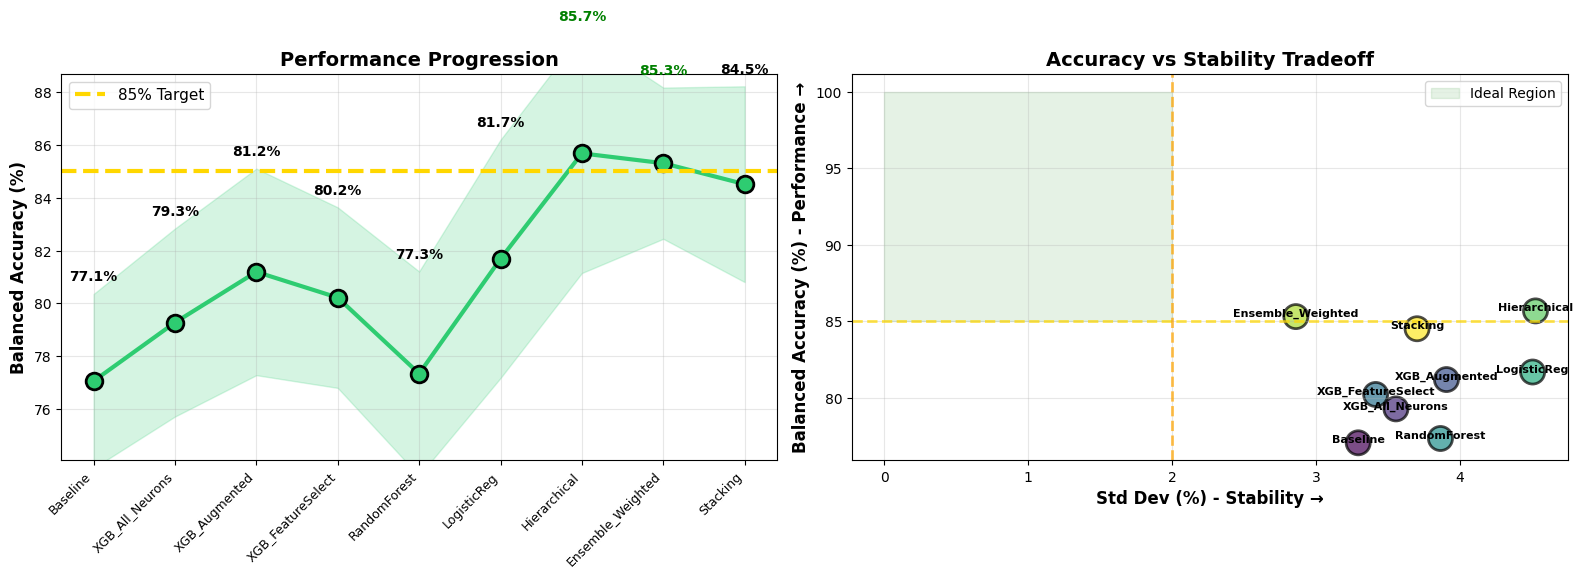


Generating feature importance analysis...


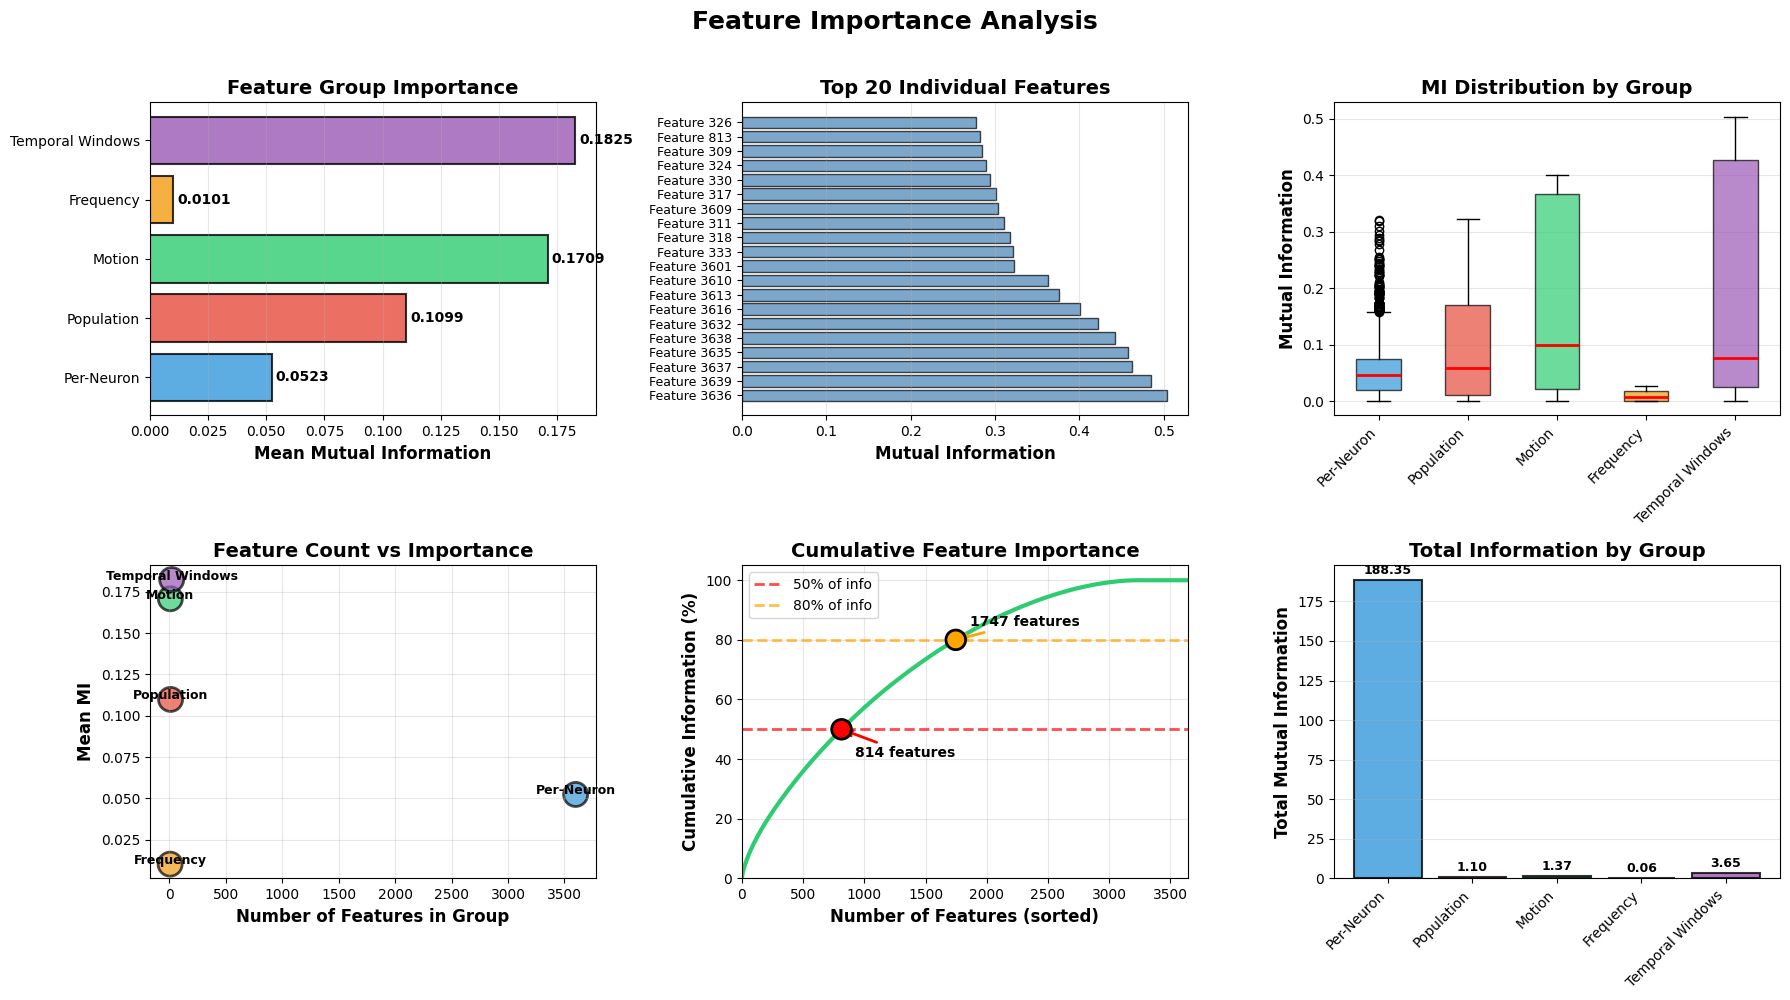

In [14]:
"""
NEURAL DECODER - PART 3: MODULAR VISUALIZATIONS

Works with any model outputs from Part 2.
Expects:
  - results: dict where keys are model names and values are tuples of (confusion_matrix, list_of_fold_accuracies)
  - raw_trials: list of trial data
  - labels: array of class labels
  - neuron_indices: indices of neurons used
  - class_names: list of class name strings

Optional (for feature importance plot):
  - extract_all_features: function to extract features
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.feature_selection import mutual_info_classif

print(f"  - {len(results)} models detected")
print(f"  - {len(class_names)} classes")
print(f"  - {len(raw_trials)} trials")
print(f"  - {len(neuron_indices)} neurons selected\n")

# Extract model information dynamically
model_names = list(results.keys())
n_models = len(model_names)
n_classes = len(class_names)

# Generate color palette dynamically
def generate_colors(n):
    """Generate n distinct colors"""
    base_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6',
                   '#1abc9c', '#e67e22', '#34495e', '#16a085', '#c0392b']
    if n <= len(base_colors):
        return base_colors[:n]
    # If we need more colors, cycle through
    colors = []
    for i in range(n):
        colors.append(base_colors[i % len(base_colors)])
    return colors

colors = generate_colors(n_models)
colors_stim = generate_colors(n_classes)

#=============================================================================
# 1. TEMPORAL DRIFT ANALYSIS
#=============================================================================

print("\nGenerating drift analysis...")

fig1 = plt.figure(figsize=(16, 10))

mean_activity = np.array([np.mean(trial[:, neuron_indices]) for trial in raw_trials])
slope, intercept, r_value, p_value, _ = linregress(np.arange(len(mean_activity)), mean_activity)

# Plot 1: Activity over time
ax1 = plt.subplot(2, 2, 1)
ax1.plot(mean_activity, alpha=0.7, linewidth=1.5, color='steelblue')
ax1.plot(np.arange(len(mean_activity)),
        slope * np.arange(len(mean_activity)) + intercept,
        'r--', linewidth=3, label=f'Trend (R²={r_value**2:.3f})')
ax1.set_xlabel('Trial Number', fontweight='bold', fontsize=12)
ax1.set_ylabel('Mean Activity', fontweight='bold', fontsize=12)
ax1.set_title('Neural Activity Drift', fontweight='bold', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: By stimulus type
ax2 = plt.subplot(2, 2, 2)
for idx, class_name in enumerate(class_names):
    mask = labels == idx
    ax2.scatter(np.where(mask)[0], mean_activity[mask],
              alpha=0.6, s=40, label=class_name, color=colors_stim[idx])
ax2.set_xlabel('Trial Number', fontweight='bold', fontsize=12)
ax2.set_ylabel('Mean Activity', fontweight='bold', fontsize=12)
ax2.set_title('Activity by Stimulus Over Time', fontweight='bold', fontsize=14)
ax2.legend(fontsize=10, loc='best', ncol=max(1, n_classes // 3))
ax2.grid(alpha=0.3)

# Plot 3: Early vs late distribution
ax3 = plt.subplot(2, 2, 3)
n = len(mean_activity)
early = mean_activity[:n//3]
late = mean_activity[2*n//3:]
ax3.hist(early, bins=25, alpha=0.6, label=f'Early (n={len(early)})',
         color='#3498db', edgecolor='black')
ax3.hist(late, bins=25, alpha=0.6, label=f'Late (n={len(late)})',
         color='#e74c3c', edgecolor='black')
ax3.set_xlabel('Mean Activity', fontweight='bold', fontsize=12)
ax3.set_ylabel('Count', fontweight='bold', fontsize=12)
ax3.set_title('Early vs Late Distribution', fontweight='bold', fontsize=14)
ax3.legend(fontsize=11)
ax3.grid(alpha=0.3)

# Plot 4: Detrending effect
ax4 = plt.subplot(2, 2, 4)
detrended = mean_activity - (slope * np.arange(len(mean_activity)) + intercept)
ax4.plot(mean_activity, alpha=0.6, label='Original', linewidth=2, color='#95a5a6')
ax4.plot(detrended, alpha=0.8, label='Detrended', linewidth=2, color='#2ecc71')
ax4.set_xlabel('Trial Number', fontweight='bold', fontsize=12)
ax4.set_ylabel('Mean Activity', fontweight='bold', fontsize=12)
ax4.set_title('Detrending Effect', fontweight='bold', fontsize=14)
ax4.legend(fontsize=11)
ax4.grid(alpha=0.3)

plt.suptitle(f'Temporal Drift Analysis (p={p_value:.2e}, slope={slope:.6f})',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#=============================================================================
# 2. CONFUSION MATRICES
#=============================================================================

print("\nGenerating confusion matrices...")

# Calculate grid dimensions
n_cols = min(4, n_models)
n_rows = int(np.ceil(n_models / n_cols))

fig2 = plt.figure(figsize=(5*n_cols, 5*n_rows))

for idx, model_name in enumerate(model_names):
    ax = plt.subplot(n_rows, n_cols, idx + 1)

    cm, accs = results[model_name]
    mean_acc = np.mean(accs) * 100
    std_acc = np.std(accs) * 100

    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(np.arange(n_classes))
    ax.set_yticks(np.arange(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)

    # Add text annotations
    for i in range(n_classes):
        for j in range(n_classes):
            text_color = "white" if cm[i, j] > cm.max()/2 else "black"
            ax.text(j, i, f'{int(cm[i, j])}',
                   ha="center", va="center", color=text_color,
                   fontsize=11, fontweight='bold')

    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('True', fontsize=11, fontweight='bold')

    title_color = 'green' if mean_acc >= 85 else 'black'
    ax.set_title(f'{model_name}\n{mean_acc:.1f}% ± {std_acc:.1f}%',
                fontweight='bold', fontsize=12, color=title_color, pad=10)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Confusion Matrices - All Models', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#=============================================================================
# 3. MODEL PERFORMANCE COMPARISON
#=============================================================================

print("\nGenerating performance comparison...")

fig3 = plt.figure(figsize=(18, 6))

mean_accs = [np.mean(results[m][1]) * 100 for m in model_names]
std_accs = [np.std(results[m][1]) * 100 for m in model_names]

# Plot 1: Accuracy comparison
ax1 = plt.subplot(1, 3, 1)
bars = ax1.bar(model_names, mean_accs, yerr=std_accs,
              color=colors, alpha=0.8, capsize=8,
              edgecolor='black', linewidth=1.5)
ax1.axhline(y=85, color='gold', linestyle='--', linewidth=3,
           label='Target (85%)', alpha=0.8)
ax1.set_ylabel('Balanced Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('Model Performance', fontsize=15, fontweight='bold')
ax1.set_ylim([max(0, min(mean_accs)-5), min(100, max(mean_accs)+5)])
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)

for bar, acc in zip(bars, mean_accs):
    height = bar.get_height()
    color = 'green' if acc >= 85 else 'black'
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.8,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=color)

# Plot 2: Stability comparison
ax2 = plt.subplot(1, 3, 2)
bars = ax2.barh(model_names, std_accs, color=colors,
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.axvline(x=2.0, color='orange', linestyle='--', linewidth=3,
           label='Stable (<2%)', alpha=0.8)
ax2.set_xlabel('Std Dev (%) - Lower is Better', fontsize=13, fontweight='bold')
ax2.set_title('Model Stability', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, axis='x')

for bar, std in zip(bars, std_accs):
    color = 'green' if std < 2.0 else 'red'
    ax2.text(std + 0.1, bar.get_y() + bar.get_height()/2,
            f'{std:.2f}%', va='center', fontweight='bold', fontsize=10, color=color)

# Plot 3: Accuracy vs Stability scatter
ax3 = plt.subplot(1, 3, 3)
scatter = ax3.scatter(mean_accs, std_accs, s=400, c=colors,
                     alpha=0.7, edgecolors='black', linewidth=2)

for i, name in enumerate(model_names):
    ax3.annotate(name, (mean_accs[i], std_accs[i]),
                xytext=(0, 0), textcoords='offset points',
                fontsize=9, ha='center', va='center', fontweight='bold')

ax3.axvline(x=85, color='gold', linestyle='--', linewidth=2, alpha=0.7, label='Target Acc')
ax3.axhline(y=2.0, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Target Stability')
ax3.fill([85, 100, 100, 85], [0, 0, 2, 2], color='green', alpha=0.1, label='Ideal Zone')
ax3.set_xlabel('Mean Accuracy (%)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Std Dev (%)', fontsize=13, fontweight='bold')
ax3.set_title('Accuracy vs Stability', fontsize=15, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.suptitle('Model Performance Analysis', fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#=============================================================================
# 4. PER-CLASS PERFORMANCE
#=============================================================================

print("\nGenerating per-class analysis...")

fig4 = plt.figure(figsize=(16, max(7, n_models * 0.8)))

# Heatmap of all models x classes
ax = plt.subplot(1, 1, 1)
per_class_matrix = []
for model_name in model_names:
    cm = results[model_name][0]
    per_class_acc = np.diag(cm) / np.sum(cm, axis=1) * 100
    per_class_matrix.append(per_class_acc)

per_class_matrix = np.array(per_class_matrix)
im = ax.imshow(per_class_matrix, cmap='RdYlGn', aspect='auto', vmin=50, vmax=100)

ax.set_xticks(np.arange(n_classes))
ax.set_yticks(np.arange(n_models))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(model_names, fontsize=11)

for i in range(n_models):
    for j in range(n_classes):
        text_color = "white" if per_class_matrix[i, j] < 75 else "black"
        ax.text(j, i, f'{per_class_matrix[i, j]:.0f}',
               ha="center", va="center", color=text_color,
               fontsize=10, fontweight='bold')

ax.set_xlabel('Stimulus Class', fontsize=13, fontweight='bold')
ax.set_ylabel('Model', fontsize=13, fontweight='bold')
ax.set_title('Per-Class Accuracy Heatmap (All Models)', fontsize=15, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Accuracy (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#=============================================================================
# 5. CROSS-VALIDATION FOLD ANALYSIS
#=============================================================================

print("\nGenerating CV fold analysis...")

fig5 = plt.figure(figsize=(16, 10))

# Get number of folds from first model
n_folds = len(results[model_names[0]][1])

# Plot 1: Fold performance for all models
ax1 = plt.subplot(2, 2, 1)
for model_name, color in zip(model_names, colors):
    fold_accs = [acc * 100 for acc in results[model_name][1]]
    ax1.plot(range(1, n_folds+1), fold_accs, marker='o', linewidth=2.5,
            markersize=10, label=model_name, color=color, alpha=0.8)
ax1.axhline(y=85, color='gold', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('Fold', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax1.set_title('CV Fold Stability', fontsize=15, fontweight='bold')
ax1.legend(loc='best', fontsize=9, ncol=max(1, n_models // 4))
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, n_folds+1))

# Plot 2: Box plot of fold distribution
ax2 = plt.subplot(2, 2, 2)
fold_data = []
for model_name in model_names:
    fold_accs = [acc * 100 for acc in results[model_name][1]]
    fold_data.append(fold_accs)

bp = ax2.boxplot(fold_data, labels=model_names, patch_artist=True,
                medianprops=dict(color='red', linewidth=2),
                boxprops=dict(linewidth=1.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(y=85, color='gold', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax2.set_title('Fold Distribution', fontsize=15, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)

# Plot 3: Min/Max range per model
ax3 = plt.subplot(2, 2, 3)
min_accs = [min([acc * 100 for acc in results[m][1]]) for m in model_names]
max_accs = [max([acc * 100 for acc in results[m][1]]) for m in model_names]
ranges = [max_accs[i] - min_accs[i] for i in range(len(min_accs))]

bars = ax3.barh(model_names, ranges, left=min_accs,
               color=colors, alpha=0.7,
               edgecolor='black', linewidth=1.5)
ax3.axvline(x=85, color='gold', linestyle='--', linewidth=2, alpha=0.7)
ax3.set_xlabel('Accuracy Range (%)', fontsize=13, fontweight='bold')
ax3.set_title('Min-Max Accuracy Range', fontsize=15, fontweight='bold')
ax3.grid(alpha=0.3, axis='x')

for i, (bar, min_val, max_val) in enumerate(zip(bars, min_accs, max_accs)):
    ax3.text(min_val - 1, bar.get_y() + bar.get_height()/2,
            f'{min_val:.1f}', va='center', ha='right', fontsize=9, fontweight='bold')
    ax3.text(max_val + 1, bar.get_y() + bar.get_height()/2,
            f'{max_val:.1f}', va='center', ha='left', fontsize=9, fontweight='bold')

# Plot 4: Coefficient of variation
ax4 = plt.subplot(2, 2, 4)
cvs = [(np.std(results[m][1]) / np.mean(results[m][1])) * 100
       for m in model_names]
bars = ax4.bar(model_names, cvs, color=colors, alpha=0.8,
              edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Coefficient of Variation (%)', fontsize=13, fontweight='bold')
ax4.set_title('Relative Stability', fontsize=15, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)

for bar, cv in zip(bars, cvs):
    height = bar.get_height()
    color = 'green' if cv < 3 else 'black'
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{cv:.2f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=color)

plt.suptitle('Cross-Validation Stability Analysis', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#=============================================================================
# 6. PERFORMANCE PROGRESSION
#=============================================================================

print("\nGenerating progression plot...")

fig7, axes = plt.subplots(1, 2, figsize=(16, 6))

bal_accs = [np.mean(results[m][1]) * 100 for m in model_names]
bal_stds = [np.std(results[m][1]) * 100 for m in model_names]

# Plot 1: Performance progression
ax = axes[0]
ax.plot(range(len(model_names)), bal_accs, 'o-', linewidth=3,
       markersize=12, color='#2ecc71', markeredgecolor='black', markeredgewidth=2)
ax.fill_between(range(len(model_names)),
                np.array(bal_accs) - np.array(bal_stds),
                np.array(bal_accs) + np.array(bal_stds),
                alpha=0.2, color='#2ecc71')
ax.axhline(y=85, color='gold', linestyle='--', linewidth=3, label='85% Target')
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, fontsize=9, rotation=45, ha='right')
ax.set_ylabel('Balanced Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Performance Progression', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim([max(0, min(bal_accs)-3), min(100, max(bal_accs)+3)])

for i, (acc, std) in enumerate(zip(bal_accs, bal_stds)):
    color = 'green' if acc >= 85 else 'black'
    ax.text(i, acc + std + 0.5, f'{acc:.1f}%', ha='center',
           fontweight='bold', fontsize=10, color=color)

# Plot 2: Stability vs accuracy tradeoff
ax = axes[1]
scatter = ax.scatter(bal_stds, bal_accs, s=300, c=range(len(model_names)),
                    cmap='viridis', alpha=0.7, edgecolors='black', linewidth=2)

for i, method in enumerate(model_names):
    ax.annotate(method, (bal_stds[i], bal_accs[i]),
               fontsize=8, ha='center', fontweight='bold')

ax.axhline(y=85, color='gold', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=2.0, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Std Dev (%) - Stability →', fontweight='bold', fontsize=12)
ax.set_ylabel('Balanced Accuracy (%) - Performance →', fontweight='bold', fontsize=12)
ax.set_title('Accuracy vs Stability Tradeoff', fontweight='bold', fontsize=14)
ax.grid(alpha=0.3)

ax.fill([0, 2, 2, 0], [85, 85, 100, 100], color='green', alpha=0.1,
       label='Ideal Region')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

#=============================================================================
# 7. FEATURE IMPORTANCE ANALYSIS (OPTIONAL)
#=============================================================================

# Only run if extract_all_features function exists
if True:
  if True:
    if True:
      if 'extract_all_features' in globals():
        print("\nGenerating feature importance analysis...")

        # Compute feature importance
        X_all, _ = extract_all_features(raw_trials, neuron_indices, None)
        mi_scores = mutual_info_classif(X_all, labels, random_state=42)

        # Define feature groups dynamically
        n_neurons = len(neuron_indices)
        per_neuron_end = n_neurons * 3
        population_end = per_neuron_end + 10
        motion_end = population_end + 8
        freq_end = motion_end + 6
        window_end = freq_end + 20

        feature_groups = {
            'Per-Neuron': (0, per_neuron_end),
            'Population': (per_neuron_end, population_end),
            'Motion': (population_end, motion_end),
            'Frequency': (motion_end, freq_end),
            'Temporal Windows': (freq_end, window_end)
        }

        fig6 = plt.figure(figsize=(18, 10))

        # Plot 1: Group importance
        ax1 = plt.subplot(2, 3, 1)
        group_importance = {}
        for name, (start, end) in feature_groups.items():
            group_importance[name] = np.mean(mi_scores[start:end])

        groups = list(group_importance.keys())
        importances = list(group_importance.values())
        colors_feat = generate_colors(len(groups))
        bars = ax1.barh(groups, importances, color=colors_feat, alpha=0.8,
                       edgecolor='black', linewidth=1.5)
        ax1.set_xlabel('Mean Mutual Information', fontweight='bold', fontsize=12)
        ax1.set_title('Feature Group Importance', fontweight='bold', fontsize=14)
        ax1.grid(alpha=0.3, axis='x')

        for bar, imp in zip(bars, importances):
            ax1.text(imp + max(importances)*0.01, bar.get_y() + bar.get_height()/2,
                    f'{imp:.4f}', va='center', fontweight='bold', fontsize=10)

        # Plot 2: Top individual features
        ax2 = plt.subplot(2, 3, 2)
        top_k = min(20, len(mi_scores))
        top_indices = np.argsort(mi_scores)[-top_k:][::-1]
        ax2.barh(range(top_k), mi_scores[top_indices], color='steelblue', alpha=0.7,
                edgecolor='black', linewidth=1)
        ax2.set_yticks(range(top_k))
        ax2.set_yticklabels([f'Feature {i}' for i in top_indices], fontsize=9)
        ax2.set_xlabel('Mutual Information', fontweight='bold', fontsize=12)
        ax2.set_title(f'Top {top_k} Individual Features', fontweight='bold', fontsize=14)
        ax2.grid(alpha=0.3, axis='x')

        # Plot 3: MI distribution per group
        ax3 = plt.subplot(2, 3, 3)
        group_data = []
        group_labels = []
        for name, (start, end) in feature_groups.items():
            group_data.append(mi_scores[start:end])
            group_labels.append(name)

        bp = ax3.boxplot(group_data, labels=group_labels, patch_artist=True,
                        medianprops=dict(color='red', linewidth=2))
        for patch, color in zip(bp['boxes'], colors_feat):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax3.set_ylabel('Mutual Information', fontweight='bold', fontsize=12)
        ax3.set_title('MI Distribution by Group', fontweight='bold', fontsize=14)
        ax3.grid(alpha=0.3, axis='y')
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)

        # Plot 4: Feature count vs importance scatter
        ax4 = plt.subplot(2, 3, 4)
        feature_counts = [end - start for start, end in feature_groups.values()]
        avg_importances = list(group_importance.values())

        scatter = ax4.scatter(feature_counts, avg_importances, s=300, c=colors_feat,
                             alpha=0.7, edgecolors='black', linewidth=2)
        for i, name in enumerate(groups):
            ax4.annotate(name, (feature_counts[i], avg_importances[i]),
                        fontsize=9, ha='center', fontweight='bold')

        ax4.set_xlabel('Number of Features in Group', fontweight='bold', fontsize=12)
        ax4.set_ylabel('Mean MI', fontweight='bold', fontsize=12)
        ax4.set_title('Feature Count vs Importance', fontweight='bold', fontsize=14)
        ax4.grid(True, alpha=0.3)

        # Plot 5: Cumulative importance
        ax5 = plt.subplot(2, 3, 5)
        sorted_mi = np.sort(mi_scores)[::-1]
        cumsum_mi = np.cumsum(sorted_mi) / np.sum(mi_scores) * 100
        ax5.plot(cumsum_mi, linewidth=3, color='#2ecc71')
        ax5.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='50% of info')
        ax5.axhline(y=80, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='80% of info')

        idx_50 = np.argmax(cumsum_mi >= 50)
        idx_80 = np.argmax(cumsum_mi >= 80)
        ax5.scatter([idx_50, idx_80], [50, 80], s=200, c=['red', 'orange'],
                   zorder=5, edgecolors='black', linewidth=2)
        ax5.annotate(f'{idx_50} features', (idx_50, 50), xytext=(10, -20),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red', lw=2))
        ax5.annotate(f'{idx_80} features', (idx_80, 80), xytext=(10, 10),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='orange', lw=2))

        ax5.set_xlabel('Number of Features (sorted)', fontweight='bold', fontsize=12)
        ax5.set_ylabel('Cumulative Information (%)', fontweight='bold', fontsize=12)
        ax5.set_title('Cumulative Feature Importance', fontweight='bold', fontsize=14)
        ax5.legend(fontsize=10)
        ax5.grid(True, alpha=0.3)
        ax5.set_xlim([0, len(mi_scores)])
        ax5.set_ylim([0, 105])

        # Plot 6: Group comparison bar chart
        ax6 = plt.subplot(2, 3, 6)
        total_mi_per_group = [np.sum(mi_scores[start:end]) for start, end in feature_groups.values()]
        bars = ax6.bar(groups, total_mi_per_group, color=colors_feat, alpha=0.8,
                      edgecolor='black', linewidth=1.5)
        ax6.set_ylabel('Total Mutual Information', fontweight='bold', fontsize=12)
        ax6.set_title('Total Information by Group', fontweight='bold', fontsize=14)
        ax6.grid(alpha=0.3, axis='y')
        plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)

        for bar, total in zip(bars, total_mi_per_group):
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height + max(total_mi_per_group)*0.01,
                    f'{total:.2f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

        plt.suptitle('Feature Importance Analysis', fontsize=18, fontweight='bold', y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()
